# NB4: 机器学习信号

## 研究假设
> NB3证明单因子（Z-score）可以实现正收益，但持仓占比低（34%）限制了收益上限。本Notebook用机器学习做多因子组合，尝试更精准地识别入场时机，提高持仓效率。

## 决策日志
| 决策 | 选择 | 为什么 |
|------|------|--------|
| 模型 | XGBoost | 对表格数据效果好，可解释性强（特征重要性），不需要大量调参 |
| 目标变量 | 未来24h收益方向（涨/跌） | 二分类问题，比预测精确价格更现实 |
| 特征 | 技术指标+统计特征 | 复用NB2和NB3的指标作为输入特征 |
| 验证方式 | 时间序列分割 | 不能用随机划分，必须用过去预测未来，避免未来数据泄露 |

---
## 1. 加载数据

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import json
import warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei']
matplotlib.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_parquet('../data/btc_usdt_1h_clean.parquet')
with open('../data/config.json', 'r') as f:
    CONFIG = json.load(f)

print(f"已加载: {len(df):,} 条 {CONFIG['symbol']} {CONFIG['timeframe']} K线")

已加载: 35,064 条 BTC/USDT 1h K线


---
## 2. 特征工程

把NB2和NB3的指标全部作为输入特征，让模型自己学习哪些有用。

In [2]:
def build_features(df):
    """构建特征矩阵"""
    data = df.copy()
    
    # --- 价格类 ---
    for w in [12, 24, 72, 168]:
        data[f'ma_{w}'] = data['close'].rolling(w).mean()
        data[f'ma_ratio_{w}'] = data['close'] / data[f'ma_{w}']
    
    # --- 动量类 ---
    for w in [6, 12, 24, 72]:
        data[f'return_{w}h'] = data['close'].pct_change(w)
    
    # --- RSI ---
    for period in [14, 48, 168]:
        delta = data['close'].diff()
        gain = delta.where(delta > 0, 0).rolling(period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(period).mean()
        rs = gain / loss
        data[f'rsi_{period}'] = 100 - (100 / (1 + rs))
    
    # --- Z-score ---
    for w in [72, 168, 336]:
        rolling_mean = data['close'].rolling(w).mean()
        rolling_std = data['close'].rolling(w).std()
        data[f'zscore_{w}'] = (data['close'] - rolling_mean) / rolling_std
    
    # --- 波动率 ---
    for w in [24, 72, 168]:
        data[f'volatility_{w}'] = data['returns'].rolling(w).std()
    
    # --- 成交量 ---
    for w in [24, 72]:
        data[f'volume_ratio_{w}'] = data['volume'] / data['volume'].rolling(w).mean()
    
    # --- 布林带 ---
    bb_mid = data['close'].rolling(20).mean()
    bb_std = data['close'].rolling(20).std()
    data['bb_position'] = (data['close'] - bb_mid) / (2 * bb_std)
    
    # --- 目标变量：未来24h收益方向 ---
    data['future_return'] = data['close'].shift(-24) / data['close'] - 1
    data['target'] = (data['future_return'] > 0).astype(int)
    
    return data

df_feat = build_features(df)

# 特征列表
feature_cols = [c for c in df_feat.columns if c not in 
    ['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns',
     'typical_price', 'bar_range', 'volume_usd', 'is_anomaly',
     'future_return', 'target'] and not c.startswith('ma_') or c.startswith('ma_ratio_')]

# 去掉均线原始值，只保留比率
feature_cols = [c for c in df_feat.columns if c not in 
    ['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns',
     'typical_price', 'bar_range', 'volume_usd', 'is_anomaly',
     'future_return', 'target', 'ma_12', 'ma_24', 'ma_72', 'ma_168']]

print(f"特征数量: {len(feature_cols)}")
print(f"特征列表: {feature_cols}")

特征数量: 20
特征列表: ['ma_ratio_12', 'ma_ratio_24', 'ma_ratio_72', 'ma_ratio_168', 'return_6h', 'return_12h', 'return_24h', 'return_72h', 'rsi_14', 'rsi_48', 'rsi_168', 'zscore_72', 'zscore_168', 'zscore_336', 'volatility_24', 'volatility_72', 'volatility_168', 'volume_ratio_24', 'volume_ratio_72', 'bb_position']


---
## 3. 训练模型

用时间序列分割：前70%训练，后30%测试。绝不能用未来数据。

In [3]:
# 去掉NaN行
df_ml = df_feat[feature_cols + ['target']].dropna()
print(f"有效样本数: {len(df_ml):,}")

# 时间序列分割：前70%训练，后30%测试
split_idx = int(len(df_ml) * 0.7)
train = df_ml.iloc[:split_idx]
test = df_ml.iloc[split_idx:]

X_train, y_train = train[feature_cols], train['target']
X_test, y_test = test[feature_cols], test['target']

print(f"训练集: {len(train):,} 条 ({train.index[0].strftime('%Y-%m')} -> {train.index[-1].strftime('%Y-%m')})")
print(f"测试集: {len(test):,} 条 ({test.index[0].strftime('%Y-%m')} -> {test.index[-1].strftime('%Y-%m')})")
print(f"目标分布 (训练): 涨 {y_train.mean():.1%} / 跌 {1-y_train.mean():.1%}")
print(f"目标分布 (测试): 涨 {y_test.mean():.1%} / 跌 {1-y_test.mean():.1%}")

有效样本数: 34,729
训练集: 24,310 条 (2021-01 -> 2023-10)
测试集: 10,419 条 (2023-10 -> 2024-12)
目标分布 (训练): 涨 50.1% / 跌 49.9%
目标分布 (测试): 涨 53.7% / 跌 46.3%


In [4]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
)

model.fit(X_train, y_train)

# 训练集和测试集准确率
train_acc = accuracy_score(y_train, model.predict(X_train))
test_acc = accuracy_score(y_test, model.predict(X_test))

print(f"训练集准确率: {train_acc:.1%}")
print(f"测试集准确率: {test_acc:.1%}")

训练集准确率: 73.0%
测试集准确率: 50.3%


In [5]:
model_v2 = XGBClassifier(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.6,
    colsample_bytree=0.5,
    min_child_weight=50,
    reg_alpha=1.0,
    reg_lambda=5.0,
    random_state=42,
    eval_metric='logloss',
)

model_v2.fit(X_train, y_train)

train_acc = accuracy_score(y_train, model_v2.predict(X_train))
test_acc = accuracy_score(y_test, model_v2.predict(X_test))

print(f"训练集准确率: {train_acc:.1%}")
print(f"测试集准确率: {test_acc:.1%}")
print(f"过拟合差距: {train_acc - test_acc:.1%}")

训练集准确率: 58.9%
测试集准确率: 50.7%
过拟合差距: 8.2%


In [6]:
# 用概率而不是硬分类
proba = model_v2.predict_proba(X_test)[:, 1]  # 上涨概率

# 看看概率分布
print("预测概率分布:")
print(f"  均值: {proba.mean():.3f}")
print(f"  标准差: {proba.std():.3f}")
print(f"  最小: {proba.min():.3f}")
print(f"  最大: {proba.max():.3f}")

# 不同置信度阈值的准确率
for threshold in [0.55, 0.60, 0.65, 0.70]:
    high_conf = proba > threshold
    if high_conf.sum() > 0:
        acc = accuracy_score(y_test[high_conf], (proba[high_conf] > 0.5).astype(int))
        print(f"  概率>{threshold}: {high_conf.sum()} 次信号, 准确率 {acc:.1%}")
    else:
        print(f"  概率>{threshold}: 无信号")

预测概率分布:
  均值: 0.478
  标准差: 0.058
  最小: 0.371
  最大: 0.722
  概率>0.55: 1474 次信号, 准确率 55.6%
  概率>0.6: 118 次信号, 准确率 59.3%
  概率>0.65: 20 次信号, 准确率 45.0%
  概率>0.7: 2 次信号, 准确率 0.0%


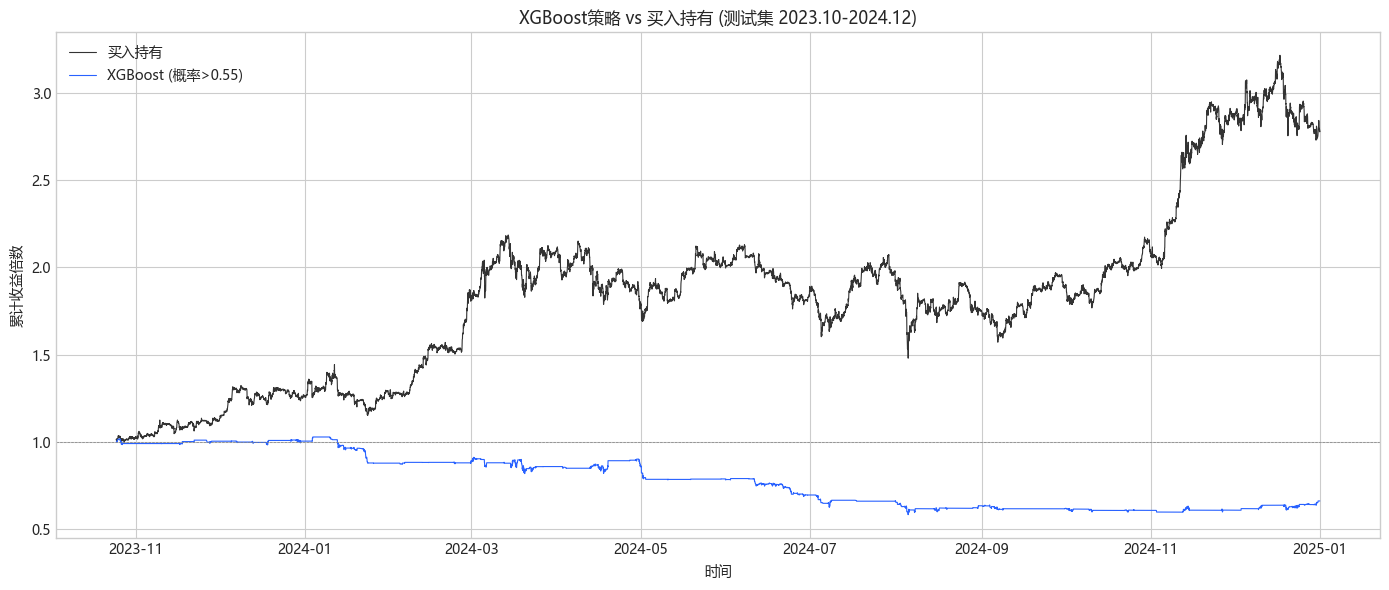

,总收益,年化收益,年化波动,夏普比率,最大回撤,胜率
策略,,,,,,
买入持有,174.2%,133.5%,50.7%,2.63,-32.3%,51.3%
XGBoost (概率>0.55),-33.9%,-29.4%,22.7%,-1.29,-43.3%,43.4%


In [9]:
def backtest_sized(df, fee=0.001):
    """支持分仓的回测"""
    data = df.copy()
    data['strategy_returns'] = data['signal'].shift(1) * data['returns']
    position_change = data['signal'].diff().abs()
    data['strategy_returns'] -= position_change * fee
    data['cumulative_market'] = (1 + data['returns']).cumprod()
    data['cumulative_strategy'] = (1 + data['strategy_returns']).cumprod()
    return data

def calc_metrics(data, strategy_name):
    ret = data['strategy_returns'].dropna()
    cum = data['cumulative_strategy'].dropna()
    total_return = cum.iloc[-1] / cum.iloc[0] - 1
    annual_return = (1 + total_return) ** (8760 / len(ret)) - 1
    annual_vol = ret.std() * np.sqrt(8760)
    sharpe = annual_return / annual_vol if annual_vol != 0 else 0
    peak = cum.cummax()
    max_drawdown = ((cum - peak) / peak).min()
    trades = ret[ret != 0]
    win_rate = (trades > 0).sum() / len(trades) if len(trades) > 0 else 0
    return {
        '策略': strategy_name,
        '总收益': f"{total_return:.1%}",
        '年化收益': f"{annual_return:.1%}",
        '年化波动': f"{annual_vol:.1%}",
        '夏普比率': f"{sharpe:.2f}",
        '最大回撤': f"{max_drawdown:.1%}",
        '胜率': f"{win_rate:.1%}",
    }

# 构建测试集的信号
df_test_bt = df.loc[test.index].copy()
df_test_bt['signal'] = 0.0
df_test_bt.loc[test.index, 'signal'] = (proba > 0.55).astype(float)

df_ml_bt = backtest_sized(df_test_bt)

# 买入持有基准（同一时段）
df_hold_test = df.loc[test.index].copy()
df_hold_test['strategy_returns'] = df_hold_test['returns']
df_hold_test['cumulative_strategy'] = (1 + df_hold_test['returns']).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_ml_bt.index, df_ml_bt['cumulative_market'], linewidth=0.8, color='#333', label='买入持有')
ax.plot(df_ml_bt.index, df_ml_bt['cumulative_strategy'], linewidth=0.8, color='#2962FF', label='XGBoost (概率>0.55)')
ax.axhline(1, color='gray', linestyle='--', linewidth=0.5)
ax.set_title('XGBoost策略 vs 买入持有 (测试集 2023.10-2024.12)')
ax.set_ylabel('累计收益倍数')
ax.set_xlabel('时间')
ax.legend()
plt.tight_layout()
plt.show()

results = [
    calc_metrics(df_hold_test, '买入持有'),
    calc_metrics(df_ml_bt, 'XGBoost (概率>0.55)'),
]
pd.DataFrame(results).set_index('策略')

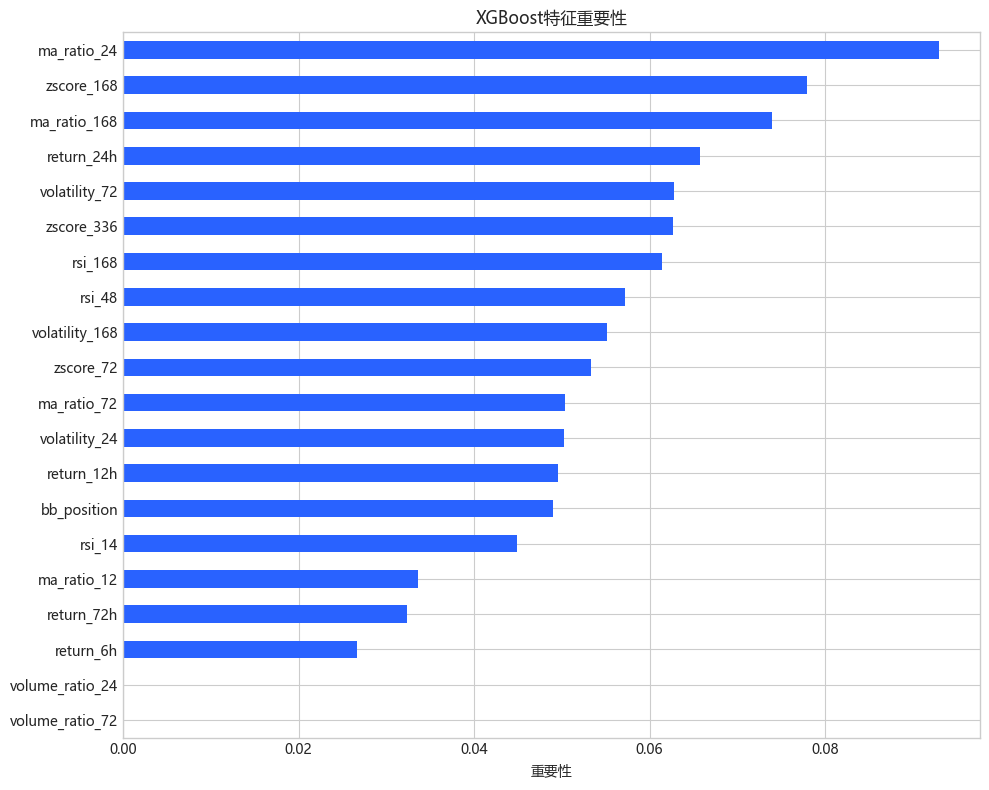


Top 5 特征:
  volatility_72: 0.063
  return_24h: 0.066
  ma_ratio_168: 0.074
  zscore_168: 0.078
  ma_ratio_24: 0.093


In [10]:
# 特征重要性
importance = pd.Series(model_v2.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
importance.plot(kind='barh', ax=ax, color='#2962FF')
ax.set_title('XGBoost特征重要性')
ax.set_xlabel('重要性')
plt.tight_layout()
plt.show()

print("\nTop 5 特征:")
for feat, imp in importance.tail(5).items():
    print(f"  {feat}: {imp:.3f}")

---
## 小结

**模型表现**
- XGBoost测试集准确率仅50.7%，接近随机猜测
- 即使只取高置信度信号（概率>0.55），回测仍然亏损-33.9%
- 过拟合是核心问题：训练集73%/58.9% vs 测试集50.3%/50.7%

**特征重要性发现**
1. 最重要的特征是价格相对均线的位置（ma_ratio_24）和Z-score（zscore_168），与NB2/NB3的手动发现一致
2. 成交量特征几乎无用，说明BTC的量价关系可能不像传统金融市场那么强
3. 中长周期特征（168h/336h）比短周期（6h/12h）更重要，短周期噪声太大

**为什么ML没能跑赢简单规则**
1. BTC小时级别的价格序列接近随机游走，可预测性本身就很低
2. 20个特征对于35000条样本来说信息量有限，且特征之间相关性高（均线比率和Z-score本质上度量的是同一件事）
3. 市场结构在变化（2021牛市 vs 2022熊市 vs 2024牛市），训练集学到的模式在测试集可能已经失效

**全项目回顾**
| Notebook | 最优策略 | 总收益 | 夏普 |
|----------|----------|--------|------|
| NB2 经典指标 | 均线交叉 | -6.9% | -0.04 |
| NB3 统计驱动 | Z-score (7天 Z<=-1.5) | +35.3% | 0.19 |
| NB4 机器学习 | XGBoost (概率>0.55) | -33.9% | -1.29 |
| 基准 | 买入持有 | +218.2% | 0.53 |

**核心结论**
- 在BTC这种长期上涨+高波动的市场中，简单的统计规则（Z-score）反而优于复杂的ML模型
- 最大的alpha来源不是择时，而是承受波动的能力——买入持有以-77%的回撤为代价换取了+218%的收益
- 复杂度不等于有效性，这对产品决策同样适用